# REPLAY metagradient demo

Quick, self-contained demo of the **REPLAY** engine (`replay.py`): compute the metagradient
`d phi / d theta` of a held-out reconstruction objective with respect to cluster-weight logits, by
differentiating through a short deterministic MAE-ViT training trajectory.

We compute it two ways and check they agree:

1. **Explicit backprop** through the *fully unrolled* trajectory (`metagrad.unrolled_objective`,
   stores every intermediate state -- `O(T)` memory).
2. **REPLAY** -- a lazy k-ary reverse traversal that regenerates optimizer states on demand
   (`replay.replay_metagradient`, `O(k log_k(T))` state memory).

Because REPLAY changes only the memory *schedule*, the two metagradients are identical (this
is rung **L3**). Then we use the validated metagradient to actually curate the data distribution via
the signed-gradient meta-update. Runs in well under a minute on CPU in float64.

In [1]:
from __future__ import annotations

import math

import torch

from model import ViTConfig, VisionTransformerClassifier
from functional_train import SmoothAdamWConfig, initialize_train_state
from metagrad import InnerBatch, ObjectiveBatch, unrolled_objective
from replay import replay_metagradient

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # CPU float64 oracle -> crisp REPLAY == backprop match
device = torch.device("cpu")
print("torch", torch.__version__, "| device", device, "| dtype", torch.get_default_dtype())

torch 2.8.0+cu128 | device cpu | dtype torch.float64


## Tiny model + two synthetic clusters

Cluster 0 (**template**) is a shared low-frequency template plus small jitter -- the *same* structure
as the held-out objective set, so training on it transfers. Cluster 1 (**noise**) is unstructured
uniform noise that does nothing for the objective. A good curation should therefore **upweight the
template cluster**.

In [2]:
config = ViTConfig(
    image_size=16, patch_size=4,
    encoder_dim=32, encoder_depth=2, encoder_heads=4,
    mlp_ratio=2.0, num_classes=2,
)
model = VisionTransformerClassifier(config).to(device)
initial_state = initialize_train_state(model)

# One shared low-frequency template; cluster 0 (class 0) and the objective are template + small
# jitter, while cluster 1 (class 1) is unstructured noise.
template_gen = torch.Generator().manual_seed(1234)
template = torch.nn.functional.interpolate(
    torch.rand(1, config.channels, 2, 2, generator=template_gen),
    size=config.image_size, mode="bilinear", align_corners=False,
)


def template_images(n, seed, jitter=0.03):
    gen = torch.Generator().manual_seed(seed)
    jit = torch.randn(n, config.channels, config.image_size, config.image_size, generator=gen)
    return (template.expand(n, config.channels, config.image_size, config.image_size) + jitter * jit).clamp(0, 1)


def noise_images(n, seed):
    gen = torch.Generator().manual_seed(seed)
    return torch.rand(n, config.channels, config.image_size, config.image_size, generator=gen)


per_cluster = 4
training_images = torch.cat([template_images(per_cluster, 1), noise_images(per_cluster, 2)]).to(device)
group_ids = torch.tensor([0] * per_cluster + [1] * per_cluster)   # 0 = template, 1 = noise
labels = group_ids                                                # clusters are the class labels
base_group_masses = torch.tensor([0.5, 0.5])                      # even base distribution D
image_ids = torch.arange(per_cluster * 2)                         # stable candidate ids (paper section)

objective_images = template_images(4, 99).to(device)             # held-out, same template family
objective_labels = torch.zeros(4, dtype=torch.long)             # objective scores class 0 (template)
objective_batch = ObjectiveBatch(objective_images, objective_labels)

T = 20
# No MAE mask: with augmentation off the inner step is a pure function of the (fixed) batch, so
# every step reuses the same images/labels/groups and determinism rests on the fixed data order.
trajectory = tuple(
    InnerBatch(training_images, labels, group_ids)
    for _ in range(T)
)

optimizer_config = SmoothAdamWConfig(learning_rate=1.5e-2, betas=(0.9, 0.99), eps=1e-4, weight_decay=0.0)
temperature = 0.5

print(f"T={T} inner steps | clusters: {per_cluster} template + {per_cluster} noise | "
      f"objective = {objective_images.shape[0]} held-out template images")
print(f"model parameters = {sum(p.numel() for p in model.parameters()):,}")

T=20 inner steps | clusters: 4 template + 4 noise | objective = 4 held-out template images
model parameters = 30,000


## Metagradient two ways

In [3]:
theta_values = torch.tensor([0.0, 0.0])   # uniform start -> base distribution D

# (1) Explicit: differentiate through the FULLY UNROLLED trajectory (every state stored).
theta_explicit = theta_values.clone().requires_grad_(True)
phi_explicit = unrolled_objective(
    model, initial_state, trajectory, objective_batch,
    theta_explicit, base_group_masses, optimizer_config, temperature, True,
)
(grad_explicit,) = torch.autograd.grad(phi_explicit, theta_explicit)

# (2) REPLAY: lazy k-ary state traversal with an explicit memory/compute tradeoff.
theta_replay = theta_values.clone().requires_grad_(True)
branching_factor = 3
phi_replay, grad_replay = replay_metagradient(
    model, initial_state, trajectory, objective_batch,
    theta_replay, base_group_masses, optimizer_config, temperature,
    branching_factor=branching_factor,
)

tree_depth = math.ceil(math.log(T + 1, branching_factor))
print(f"explicit (store-all, O(T) mem)        phi={phi_explicit.item():.10f}  grad={grad_explicit.tolist()}")
print(f"REPLAY  (k={branching_factor}, depth={tree_depth})       phi={phi_replay.item():.10f}  grad={grad_replay.tolist()}")

explicit (store-all, O(T) mem)        phi=0.0433922561  grad=[-0.01627519315012542, 0.01627519315012542]
REPLAY  (k=3, depth=3)       phi=0.0433922561  grad=[-0.01627519315012542, 0.01627519315012542]


## Validate: REPLAY == explicit backprop

In [4]:
dtype = torch.get_default_dtype()
rtol, atol = (1e-9, 1e-11) if dtype == torch.float64 else (1e-4, 1e-6)  # L3 bars (VERIFICATION.md sec 7)
torch.testing.assert_close(phi_replay, phi_explicit.detach(), rtol=rtol, atol=atol)
torch.testing.assert_close(grad_replay, grad_explicit, rtol=rtol, atol=atol)

max_abs = (grad_replay - grad_explicit).abs().max().item()
cosine = torch.nn.functional.cosine_similarity(grad_replay, grad_explicit, dim=0).item()
signs_match = torch.equal(grad_replay.sign(), grad_explicit.sign())
print(f"dtype={dtype} | max |delta grad| = {max_abs:.2e}   cosine = {cosine:.12f}   signs match = {signs_match}")
print("PASS: REPLAY metagradient == explicit unrolled backprop (within the L3 bar for this precision)")

dtype=torch.float64 | max |delta grad| = 0.00e+00   cosine = 1.000000000000   signs match = True
PASS: REPLAY metagradient == explicit unrolled backprop (within the L3 bar for this precision)


## Equivalence holds across trajectory lengths

Store-all keeps all `O(T)` states; REPLAY stores at most `O(k log_k(T))` optimizer states and
regenerates the rest during reverse traversal -- same metagradient, less memory.

In [5]:
print(f"{'T':>4}  {'#segments':>10}  {'max|delta grad|':>16}")
for T_try in (8, 16, 32, 64):
    traj = tuple(
        InnerBatch(training_images, labels, group_ids)
        for _ in range(T_try)
    )
    te = theta_values.clone().requires_grad_(True)
    (ge,) = torch.autograd.grad(
        unrolled_objective(model, initial_state, traj, objective_batch,
                           te, base_group_masses, optimizer_config, temperature, True),
        te,
    )
    tr = theta_values.clone().requires_grad_(True)
    _, gr = replay_metagradient(model, initial_state, traj, objective_batch,
                                tr, base_group_masses, optimizer_config, temperature,
                                branching_factor=3)
    depth = math.ceil(math.log(T_try + 1, 3))
    print(f"{T_try:>4}  {depth:>10}  {(gr - ge).abs().max().item():>16.2e}")

   T   #segments   max|delta grad|


   8           3          0.00e+00


  16           4          0.00e+00


  32           6          0.00e+00


  64           8          0.00e+00


## Use it: curate the distribution with the signed-gradient meta-update

`theta <- theta - alpha_k * sign(grad)`, recomputing the metagradient with REPLAY each meta-step. We
**anneal** the step `alpha_k` geometrically: constant-step sign-descent limit-cycles around the
optimum (a fixed stride can only bracket it), so a shrinking step is what lets it converge. With a
strong, well-conditioned signal the *sign* of the gradient is robust, so this curation behaves the
same in fp32 and fp64. Expect `w[template]` to climb toward 1 and the held-out `phi` to fall.

In [6]:
alpha0 = 0.25
decay = 0.8
meta_steps = 15
theta = torch.zeros(2, requires_grad=True)
history = []
for k in range(meta_steps + 1):
    phi, g = replay_metagradient(model, initial_state, trajectory, objective_batch,
                                 theta, base_group_masses, optimizer_config, temperature,
                                 branching_factor=3)
    w = torch.softmax(theta.detach() / temperature, dim=0)
    history.append((k, phi.item(), w[0].item(), w[1].item()))
    if k < meta_steps:
        with torch.no_grad():
            theta -= (alpha0 * decay ** k) * g.sign()

print(f"{'meta-step':>9}  {'phi (held-out CE)':>18}  {'w[template]':>12}  {'w[noise]':>9}")
for k, phi, w0, w1 in history:
    print(f"{k:>9}  {phi:>18.6f}  {w0:>12.3f}  {w1:>9.3f}")
print(f"\nphi: {history[0][1]:.6f} -> {history[-1][1]:.6f}   |   "
      f"w[template]: {history[0][2]:.3f} -> {history[-1][2]:.3f}")

meta-step  phi (held-out MSE)   w[template]   w[noise]
        0            0.043392         0.500      0.500
        1            0.037996         0.731      0.269
        2            0.036412         0.858      0.142
        3            0.035681         0.920      0.080
        4            0.035408         0.950      0.050
        5            0.035319         0.966      0.034
        6            0.035287         0.976      0.024
        7            0.035266         0.981      0.019
        8            0.035251         0.985      0.015
        9            0.035241         0.987      0.013
       10            0.035235         0.989      0.011
       11            0.035230         0.990      0.010
       12            0.035227         0.991      0.009
       13            0.035225         0.991      0.009
       14            0.035223         0.992      0.008
       15            0.035222         0.992      0.008

phi: 0.043392 -> 0.035222   |   w[template]: 0.500 -> 0.992


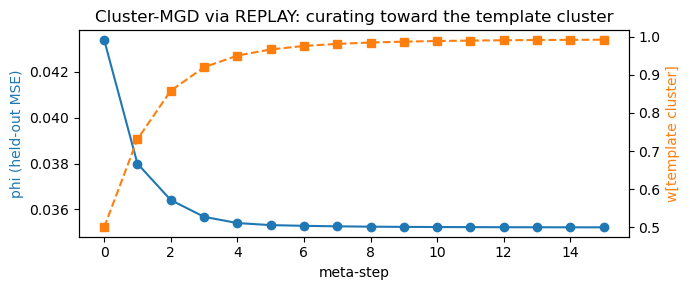

In [7]:
import matplotlib.pyplot as plt

ks = [h[0] for h in history]
phis = [h[1] for h in history]
w0s = [h[2] for h in history]

fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(ks, phis, "o-", color="C0")
ax1.set_xlabel("meta-step")
ax1.set_ylabel("phi (held-out CE)", color="C0")
ax2 = ax1.twinx()
ax2.plot(ks, w0s, "s--", color="C1")
ax2.set_ylabel("w[template cluster]", color="C1")
ax1.set_title("Cluster-MGD via REPLAY: curating toward the template cluster")
fig.tight_layout()
plt.show()

## Paper-faithful count MGD baseline

The existing demo above uses this project's **persistent cluster-softmax** parameterization: cluster
weights affect every inner-training step. The paper's dataset-selection baseline is different:

1. maintain a non-negative integer count for every original candidate;
2. build a fixed-budget training trajectory by repeating candidates according to those counts;
3. inject zero-initialized continuous perturbations at one chosen inner step;
4. use that metagradient to update the integer counts for the next outer step.

The cells below reuse the same model, template/noise candidate pool, held-out objective, and Smooth
AdamW configuration. A shorter inner trajectory keeps this correctness demo quick.

In [8]:
from paper_mgd import (
    CandidatePool,
    PaperMGDConfig,
    build_count_trajectory,
    initialize_counts,
    make_probe_batch,
    paper_mgd_outer_step,
    paper_replay_metagradient,
    paper_unrolled_objective,
)

paper_T = 8
paper_batch_size = training_images.shape[0]
perturbation_step = paper_T - 2
candidate_pool = CandidatePool(training_images, image_ids.to(torch.long), labels.to(torch.long))
initial_counts = initialize_counts(candidate_pool.num_candidates)
all_candidates = torch.arange(candidate_pool.num_candidates)

count_trajectory = build_count_trajectory(
    candidate_pool,
    initial_counts,
    inner_steps=paper_T,
    batch_size=paper_batch_size,
    shuffle_seed=101,
)
probe_batch = make_probe_batch(candidate_pool, all_candidates)

# The paper differentiates at z=0. First verify recursive REPLAY changes only memory scheduling.
z_unrolled = torch.zeros(candidate_pool.num_candidates, requires_grad=True)
phi_paper_unrolled = paper_unrolled_objective(
    model,
    initial_state,
    count_trajectory,
    probe_batch,
    objective_batch,
    perturbation_step,
    z_unrolled,
    optimizer_config,
    probe_chunk_size=4,
    create_graph=True,
)
(grad_paper_unrolled,) = torch.autograd.grad(phi_paper_unrolled, z_unrolled)

z_replay = torch.zeros(candidate_pool.num_candidates, requires_grad=True)
phi_paper_replay, grad_paper_replay = paper_replay_metagradient(
    model,
    initial_state,
    count_trajectory,
    probe_batch,
    objective_batch,
    perturbation_step,
    z_replay,
    optimizer_config,
    probe_chunk_size=4,
    branching_factor=3,
)

torch.testing.assert_close(phi_paper_replay, phi_paper_unrolled.detach(), rtol=rtol, atol=atol)
torch.testing.assert_close(grad_paper_replay, grad_paper_unrolled, rtol=rtol, atol=atol)

print(f"paper trajectory: T={paper_T}, batch={paper_batch_size}, perturbation step k={perturbation_step}")
print(f"fixed inner sample budget = {paper_T * paper_batch_size}")
print(f"paper surrogate at z=0: phi={phi_paper_replay.item():.8f}")
print("mean metagradient: template={:.3e}, noise={:.3e}".format(
    grad_paper_replay[:per_cluster].mean().item(),
    grad_paper_replay[per_cluster:].mean().item(),
))
print("PASS: paper count-MGD REPLAY == paper count-MGD explicit unrolled backprop")

paper trajectory: T=8, batch=8, perturbation step k=6
fixed inner sample budget = 64
paper surrogate at z=0: phi=0.07157305
mean metagradient: template=-2.146e-03, noise=2.855e-05
PASS: paper count-MGD REPLAY == paper count-MGD explicit unrolled backprop


In [9]:
def run_paper_count_policy(policy, outer_steps=3):
    counts = initial_counts.clone()
    config_paper = PaperMGDConfig(
        inner_steps=paper_T,
        batch_size=paper_batch_size,
        perturbation_step=perturbation_step,
        update_policy=policy,
        coordinate_fraction=1.0,
        exchange_fraction=0.25,
        shuffle_seed=101,
        selection_seed=303,
        probe_chunk_size=4,
        branching_factor=3,
    )
    rows = []
    for outer_step in range(outer_steps + 1):
        result = paper_mgd_outer_step(
            model,
            initial_state,
            candidate_pool,
            counts,
            objective_batch,
            optimizer_config,
            config_paper,
            outer_step=outer_step,
        )
        rows.append({
            "step": outer_step,
            "phi": result.objective.item(),
            "template_count": int(counts[:per_cluster].sum()),
            "noise_count": int(counts[per_cluster:].sum()),
            "total_count": int(counts.sum()),
            "counts": counts.tolist(),
        })
        counts = result.updated_counts
    return rows


projected_history = run_paper_count_policy("projected_sign")
fixed_budget_history = run_paper_count_policy("fixed_budget_ranked")

for name, rows in (
    ("projected_sign (Algorithm 1)", projected_history),
    ("fixed_budget_ranked (Appendix C.2)", fixed_budget_history),
):
    print(f"\n{name}")
    print(f"{'step':>4} {'phi':>11} {'template':>10} {'noise':>7} {'total':>7}  counts")
    for row in rows:
        print(
            f"{row['step']:>4} {row['phi']:>11.6f} {row['template_count']:>10} "
            f"{row['noise_count']:>7} {row['total_count']:>7}  {row['counts']}"
        )


projected_sign (Algorithm 1)
step         phi   template   noise   total  counts
   0    0.071573          4       4       8  [1, 1, 1, 1, 1, 1, 1, 1]
   1    0.064671          8       2      10  [2, 2, 2, 2, 0, 0, 2, 0]
   2    0.067416         12       6      18  [3, 3, 3, 3, 1, 1, 3, 1]
   3    0.066054         16       6      22  [4, 4, 4, 4, 2, 0, 4, 0]

fixed_budget_ranked (Appendix C.2)
step         phi   template   noise   total  counts
   0    0.071573          4       4       8  [1, 1, 1, 1, 1, 1, 1, 1]
   1    0.064600          6       2       8  [2, 1, 2, 1, 0, 1, 1, 0]
   2    0.061277          8       0       8  [3, 1, 3, 1, 0, 0, 0, 0]
   3    0.056422          8       0       8  [4, 0, 4, 0, 0, 0, 0, 0]


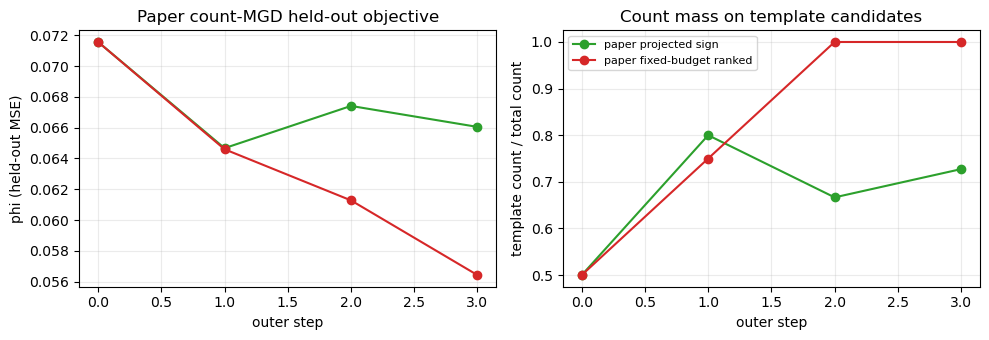

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for name, rows, color in (
    ("paper projected sign", projected_history, "C2"),
    ("paper fixed-budget ranked", fixed_budget_history, "C3"),
):
    steps = [row["step"] for row in rows]
    axes[0].plot(steps, [row["phi"] for row in rows], "o-", label=name, color=color)
    useful_mass = [
        row["template_count"] / row["total_count"] for row in rows
    ]
    axes[1].plot(steps, useful_mass, "o-", label=name, color=color)

axes[0].set_title("Paper count-MGD held-out objective")
axes[0].set_xlabel("outer step")
axes[0].set_ylabel("phi (held-out CE)")
axes[1].set_title("Count mass on template candidates")
axes[1].set_xlabel("outer step")
axes[1].set_ylabel("template count / total count")
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

### What changed relative to persistent cluster-softmax MGD?

- The paper baseline's differentiable `z` exists only to estimate candidate influence at step `k`;
  every outer step starts again from `z = 0`.
- Integer counts determine the next fixed-budget trajectory. A zero-count candidate is absent from
  training but remains probeable and can return later.
- `projected_sign` can change total count, while `fixed_budget_ranked` exchanges equal numbers of
  counts and preserves it.
- Both paths use the same lazy k-ary REPLAY core to compute the exact metagradient through training.

## Takeaways

- REPLAY's metagradient matches explicit unrolled backprop for both the persistent cluster-softmax
  method and the paper-faithful count surrogate.
- Persistent cluster-softmax MGD changes smooth cluster weights at every inner step.
- Paper count MGD uses a one-step continuous probe to update discrete candidate counts for the next
  fixed-budget training trajectory; both projected-sign and fixed-budget ranked policies are shown.
- This demo is synthetic and tiny. It is a correctness and behavior check before running a real
  comparison, not a scientific ImageNet result.